In [1]:
import sys
sys.path.append("/Users/krisztianivankai/PycharmProjects/Szakdolgozat/")
import numpy as np
import holidays
import logging

from models.fuzzy import *
from models.moving_average import forecast_moving_average
from utilities.utils import *
from evaluate.evaluate_model import get_model_score
from forecast.forecast import forecast_over_horizon

In [2]:
sales_and_stock = pd.read_csv('Szakdoga_adat.csv')
split_percentage = 0.8

In [3]:
get_date_features(sales_and_stock)

,date,sales,stock,day_of_week,month,quarter,year,year_quarter
0,2024-01-01,NaN,32,1,1,1,2024,202401
1,2024-01-02,10.0,22,2,1,1,2024,202401
2,2024-01-03,13.0,9,3,1,1,2024,202401
3,2024-01-04,25.0,34,4,1,1,2024,202401
4,2024-01-05,27.0,7,5,1,1,2024,202401
...,...,...,...,...,...,...,...,...
784,2026-02-23,76.0,335,1,2,1,2026,202601
785,2026-02-24,74.0,261,2,2,1,2026,202601
786,2026-02-25,66.0,195,3,2,1,2026,202601
787,2026-02-26,55.0,140,4,2,1,2026,202601


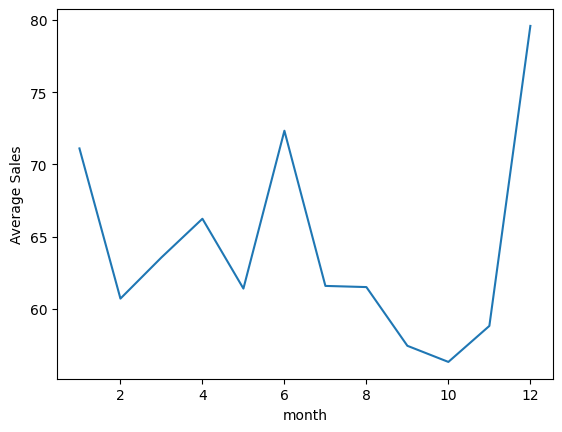

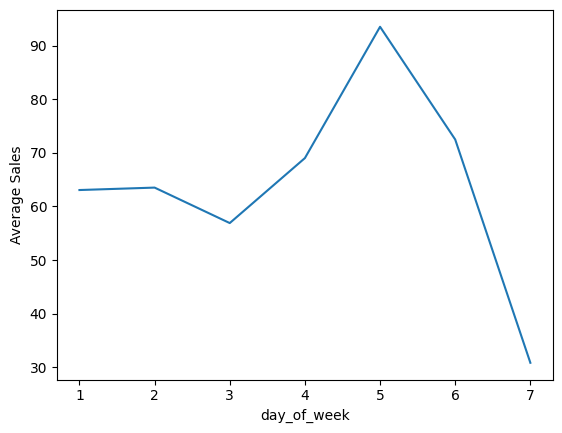

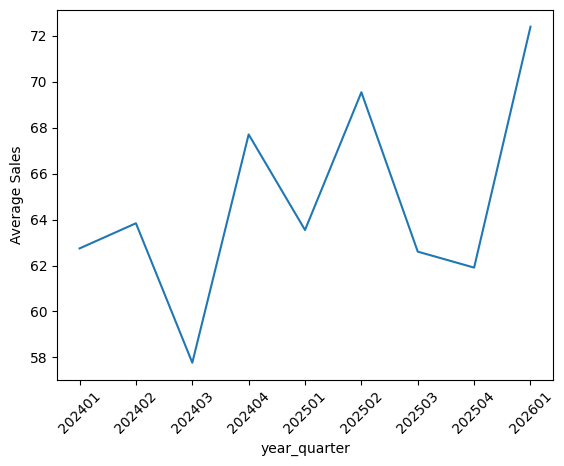

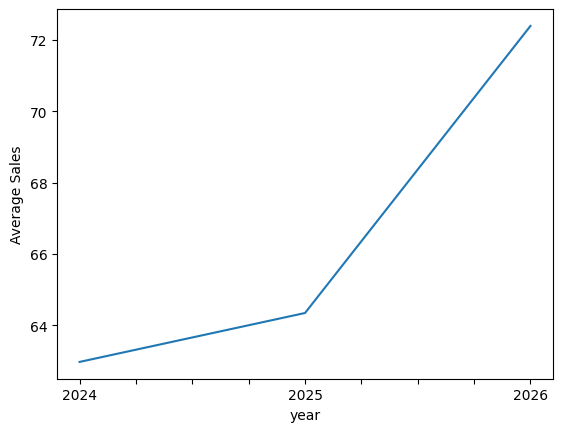

In [4]:
plot_average_by_group(sales_and_stock, 'month')
plot_average_by_group(sales_and_stock, 'day_of_week')
plot_average_by_group(sales_and_stock, 'year_quarter', 45)
plot_average_by_group(sales_and_stock, 'year')

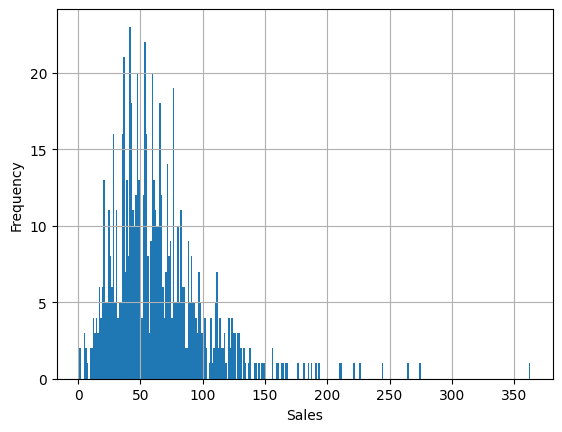

In [5]:
sales_and_stock["sales"].hist(bins=300)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

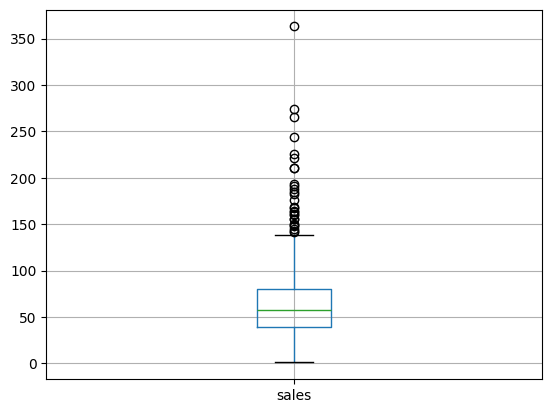

In [6]:
sales_and_stock.boxplot(column="sales")
plt.show()

In [7]:
dates = pd.DataFrame({'date': pd.date_range(start=sales_and_stock['date'].min(), end=sales_and_stock['date'].max(), freq='D')})

In [8]:
demand = dates.merge(sales_and_stock, on='date', how='left')
demand['stock'] = demand['stock'].clip(lower=0).fillna(0)
demand['sales'] = demand['sales'].clip(lower=0)
demand['out_of_stock'] = demand['stock'] <= 0
demand['demand'] = np.where(demand['stock'] > 0, demand['sales'].fillna(0), None)
demand['demand'] = pd.to_numeric(demand['demand'])
demand['demand'] = demand['demand'].interpolate(method='linear')
demand['date'] = pd.to_datetime(demand['date'], format='%Y.%m.%d')

In [9]:
observations =sales_and_stock['date'].count()
non_zero_demand_observations = sales_and_stock[sales_and_stock['sales'] != 0]['date'].count()
adi = observations/non_zero_demand_observations
adi

np.float64(1.0)

In [10]:
s_deviation = sales_and_stock['sales'].std()
mean_demand = sales_and_stock['sales'].mean()
cv = s_deviation / mean_demand
cv

np.float64(0.5981896621713417)

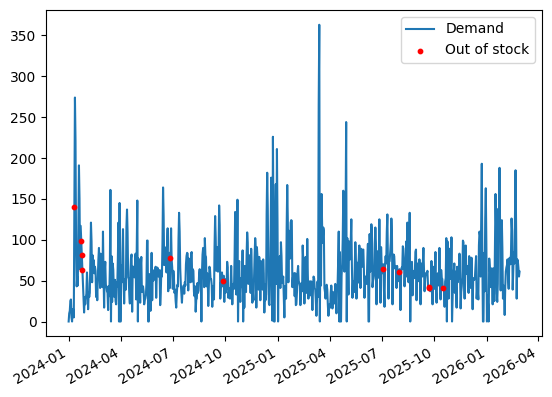

In [11]:
fig, ax = plt.subplots()
ax.plot(demand['date'], demand['demand'], label='Demand')

oos = demand[demand['out_of_stock']]
oos['date'] = pd.to_datetime(oos['date'], format='%Y.%m.%d')
ax.scatter(oos['date'], oos['demand'], color='red', s=10, label='Out of stock', zorder=5)

ax.legend()
fig.autofmt_xdate()
plt.show()

In [34]:
split_date = get_split_date(sales_and_stock['date'], split_percentage)
train_data = demand[demand['date'] < split_date].reset_index(drop=True)
test_data = demand[demand['date'] >= (split_date - timedelta(days=7))].reset_index(drop=True)[['date','demand']]

In [35]:
train_data

,date,sales,stock,day_of_week,month,quarter,year,year_quarter,out_of_stock,demand
0,2024-01-01,NaN,32,1,1,1,2024,202401,False,0.000000
1,2024-01-02,10.0,22,2,1,1,2024,202401,False,10.000000
2,2024-01-03,13.0,9,3,1,1,2024,202401,False,13.000000
3,2024-01-04,25.0,34,4,1,1,2024,202401,False,25.000000
4,2024-01-05,27.0,7,5,1,1,2024,202401,False,27.000000
...,...,...,...,...,...,...,...,...,...,...
625,2025-09-17,58.0,79,3,9,3,2025,202503,False,58.000000
626,2025-09-18,58.0,21,4,9,3,2025,202503,False,58.000000
627,2025-09-19,62.0,59,5,9,3,2025,202503,False,62.000000
628,2025-09-20,44.0,15,6,9,3,2025,202503,False,44.000000


In [36]:
test_data

,date,demand
0,2025-09-15,52.0
1,2025-09-16,59.0
2,2025-09-17,58.0
3,2025-09-18,58.0
4,2025-09-19,62.0
...,...,...
161,2026-02-23,76.0
162,2026-02-24,74.0
163,2026-02-25,66.0
164,2026-02-26,55.0


In [13]:
statistics = train_data[['demand']].describe()

In [14]:
demand_min = statistics.T["min"].to_list()[0]
demand_first_quartile = statistics.T["25%"].to_list()[0]
demand_median = statistics.T["50%"].to_list()[0]
demand_third_quartile = statistics.T["75%"].to_list()[0]
demand_max = statistics.T["max"].to_list()[0]

In [15]:
fuzzy_sets = [
    {
        "name": "VeryLowDemand",
        "type": "shoulder",
        "a": demand_min,
        "b": demand_first_quartile,
        "direction": "left",
    },
    {
        "name": "LowDemand",
        "type": "triangular",
        "a": demand_min,
        "b": demand_first_quartile,
        "c": demand_median,
    },
    {
        "name": "MediumDemand",
        "type": "triangular",
        "a": demand_first_quartile,
        "b": demand_median,
        "c": demand_third_quartile,
    },
    {
        "name": "HighDemand",
        "type": "triangular",
        "a": demand_median,
        "b": demand_third_quartile,
        "c": demand_max
    },
    {
        "name": "VeryHighDemand",
        "type": "shoulder",
        "a": demand_third_quartile,
        "b": demand_max,
        "direction": "right"
    }
]

In [16]:
lagged_train_data = create_fuzzified_lag_df(train_data, 7, fuzzy_sets)

In [17]:
fuzz_cols = [f'lag_{i}_fuzzy_set' for i in range(1, 8)]
rule_base = (
      lagged_train_data
      .dropna(subset=fuzz_cols + ['demand'])
      [['demand'] + fuzz_cols]
      .groupby(fuzz_cols)
      .mean()
      .reset_index()
  )
rule_base

,lag_1_fuzzy_set,lag_2_fuzzy_set,lag_3_fuzzy_set,lag_4_fuzzy_set,lag_5_fuzzy_set,lag_6_fuzzy_set,lag_7_fuzzy_set,demand
0,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,60.0
1,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,25.0
2,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,66.0
3,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,VeryLowDemand,28.0
4,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,HighDemand,74.5
...,...,...,...,...,...,...,...,...
528,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,LowDemand,LowDemand,LowDemand,21.0
529,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,VeryLowDemand,VeryLowDemand,VeryLowDemand,15.0
530,VeryLowDemand,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,VeryLowDemand,VeryLowDemand,15.0
531,VeryLowDemand,VeryLowDemand,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,VeryLowDemand,5.0


In [18]:
lingustic_rules = get_linguistic_form(rule_base)
lingustic_rules

,linguistic_form
0,IF LAG 1 demand IS HighDemand AND LAG 2 demand...
1,IF LAG 1 demand IS HighDemand AND LAG 2 demand...
2,IF LAG 1 demand IS HighDemand AND LAG 2 demand...
3,IF LAG 1 demand IS HighDemand AND LAG 2 demand...
4,IF LAG 1 demand IS HighDemand AND LAG 2 demand...
...,...
528,IF LAG 1 demand IS VeryLowDemand AND LAG 2 dem...
529,IF LAG 1 demand IS VeryLowDemand AND LAG 2 dem...
530,IF LAG 1 demand IS VeryLowDemand AND LAG 2 dem...
531,IF LAG 1 demand IS VeryLowDemand AND LAG 2 dem...


In [19]:
fuzzy_list = []
for i in range(-100, 400):
    value = get_all_fuzzy_membership_values(fuzzy_sets, i)
    value["demand"] = int(i)
    fuzzy_list.append(value)

In [20]:
show_sets = pd.DataFrame(fuzzy_list).melt(
    id_vars="demand",
    var_name="fuzzy_set",
    value_name="membership"
)

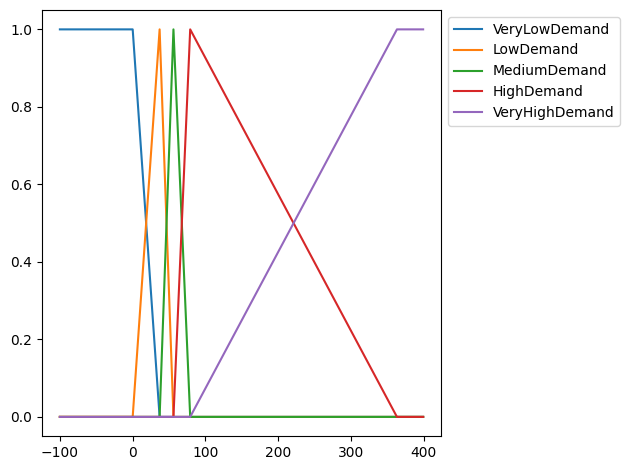

In [21]:
order = ["VeryLowDemand", "LowDemand", "MediumDemand", "HighDemand", "VeryHighDemand"]
for group in order:
    data = show_sets[show_sets["fuzzy_set"] == group]
    plt.plot(data["demand"], data["membership"], label=group)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [22]:
hu_holidays = holidays.country_holidays('HU',years=[2024,2025,2026])
holidays_pd = pd.DataFrame([hu_holidays]).melt(var_name="date", value_name="holiday")
holidays_pd = holidays_pd[~holidays_pd['holiday'].str.contains('Pihenőnap')]
holidays_pd['date'] = pd.to_datetime(holidays_pd['date'])

In [23]:
test_data = test_data.merge(holidays_pd,how='left_anti',left_on='date',right_on='date').drop(columns=['holiday'])

In [24]:
validation_start_date = test_data['date'].min() + timedelta(days=7)
forecast_horizon = (test_data['date'].max() - validation_start_date).days + 1
moving_average_forecast = forecast_over_horizon(test_data,validation_start_date,forecast_horizon,forecast_moving_average,[7])

In [25]:
fuzzy_model_forecast = forecast_over_horizon(test_data, validation_start_date, forecast_horizon, fuzzy_forecast_pipeline, [fuzzy_sets, rule_base])

In [26]:
test_data = test_data[test_data['date']>= validation_start_date]

In [27]:
fuzzy_model_forecast.merge(test_data, how='right', left_on='date', right_on='date')

,date,prediction,demand
0,2025-09-22,55.188724,40.666667
1,2025-09-23,53.206552,39.000000
2,2025-09-24,48.826346,37.000000
3,2025-09-25,50.864574,39.000000
4,2025-09-26,37.189724,74.000000
...,...,...,...
149,2026-02-23,57.803249,76.000000
150,2026-02-24,72.383802,74.000000
151,2026-02-25,72.482376,66.000000
152,2026-02-26,64.051923,55.000000


In [28]:
moving_average_forecast.merge(test_data, how='right', left_on='date', right_on='date')

,date,prediction,demand
0,2025-09-22,53.619048,40.666667
1,2025-09-23,52.000000,39.000000
2,2025-09-24,49.142857,37.000000
3,2025-09-25,46.142857,39.000000
4,2025-09-26,43.428571,74.000000
...,...,...,...
149,2026-02-23,96.142857,76.000000
150,2026-02-24,98.142857,74.000000
151,2026-02-25,96.571429,66.000000
152,2026-02-26,95.857143,55.000000


In [29]:
fuzzy_score = get_model_score(test_data, fuzzy_model_forecast)
moving_average_score = get_model_score(test_data, moving_average_forecast)

In [30]:
fuzzy_score

,mae,mae_pct,bias,bias_pct,score
0,24.304492,0.378752,-4.582306,-0.071409,0.450161


In [31]:
moving_average_score

,mae,mae_pct,bias,bias_pct,score
0,26.265306,0.409309,-0.310451,-0.004838,0.414147
